In [35]:
from swo_validation_2023_09_14 import output_dir, default_config
from misc_utils import read_jsonl_to_df, column_to as to
import seaborn as sns
import matplotlib.pyplot as plt

In [36]:
overlaps_df = read_jsonl_to_df(output_dir.glob("./*/overlaps.jsonl")).fillna(default_config)
losses_df = read_jsonl_to_df(output_dir.glob("./*/losses.jsonl")).fillna(default_config)

In [6]:
overlaps_df.groupby(['lattice', 'n_samples', 'epochs', 'n_spins', 'energy_baseline', 'net'])['iteration'].max()

lattice                                                                                                                                                                              n_samples  epochs  n_spins  energy_baseline  net                 
KagomeLattice12x12_isotropic_factor_149-150-151-152-154-155-181-182-183-184-185-186-187-188-189-190-216-217-218-219-220-221-222-223-224-225-226-251-252-253-254-255-256-257-258-291  5000       1       36       250.0            LogProbDenseNet         108
                                                                                                                                                                                                10      36       250.0            LogProbDenseNet         174
                                                                                                                                                                                                                 1000.0           LogProbDenseNet    

KeyboardInterrupt: 

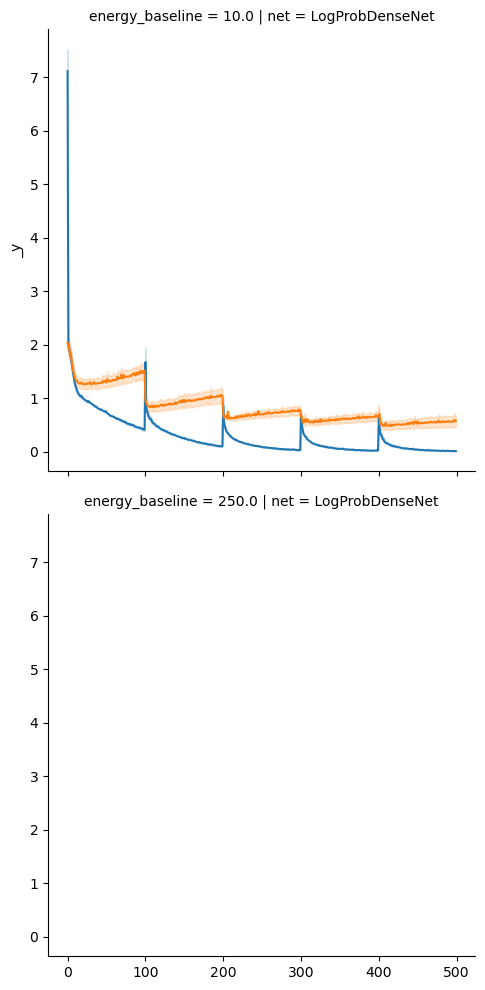

In [7]:
# sns.relplot(
#     losses_df.query('n_spins == 24 and iteration < 5 and epochs == 100').melt(
#         id_vars=["iteration", "epoch", "global_epoch", "energy_baseline", "epochs", "reset_network", "n_spins", "net"],
#         value_vars=["loss_train", "loss_validation"],
#         value_name="loss",
#     ),
#     x="global_epoch",
#     y="loss",
#     hue="variable",
#     kind="line",
#     row="energy_baseline",
#     col='net'
# ).set(yscale='log')

In [8]:
overlaps_df.query("not use_symmetries")[['n_samples', 'epochs']]

,n_samples,epochs
0,5000,10
1,5000,10
2,5000,10
3,5000,10
4,5000,10
...,...,...
1127,5000,10
1128,5000,10
1129,5000,10
1130,5000,10


In [9]:
overlaps_df.describe(include=['O'])

,alpha,mode,lattice,net,lattice_name
count,0,1408,1408,1408,1408
unique,0,1,4,2,2
top,NaN,power,KagomeLattice12x12_isotropic_factor_149-150-15...,LogProbDenseNet,kagome27
freq,NaN,1408,582,1182,927


In [10]:
def describe(df):
    df_ = df.select_dtypes(exclude=['int', 'float'])
    for col in df_.columns:
        print(col)
        for value in df_[col].unique():
            print(f"  - {value}")
    df_ = df.select_dtypes(include=['int', 'float'])
    for col in df_.columns:
        print(col)
        print(f"  : [{df_[col].min():.3f}\t{df_[col].mean():.3f}\t{df_[col].max():.3f}]")
     

In [11]:
describe(overlaps_df)

alpha
  - None
mode
  - power
lattice
  - KagomeLattice2x4
  - KagomeLattice12x12_isotropic_factor_149-150-151-152-154-155-181-182-183-184-185-186-187-188-189-190-216-217-218-219-220-221-222-223-224-225-226-251-252-253-254-255-256-257-258-291
  - KagomeLattice12x12_isotropic_factor_149-151-152-182-183-184-185-186-187-188-189-190-217-218-219-220-221-222-223-224-225-252-253-254-255-256-258
  - KagomeLattice2x5
reset_network
  - False
net
  - LogProbDenseNet
  - SplitGroupResConvNet
use_symmetries
  - False
  - True
lattice_name
  - kagome27
  - kagome36
early_stop
  - False
  - True
iteration
  : [0.000	35.408	174.000]
initial_ground_state_overlap_test
  : [0.185	0.625	0.866]
new_ground_state_overlap_test
  : [0.078	0.404	0.865]
run
  : [0.000	0.000	0.000]
n_samples
  : [5000.000	5000.000	5000.000]
energy_baseline
  : [10.000	246.570	1000.000]
n_spins
  : [24.000	30.294	36.000]
epochs
  : [1.000	124.296	1000.000]
epoch
  : [0.000	5.270	10.000]
power_iterations
  : [50.000	203.729	500.000

In [12]:
def concat_columns(columns):
    def wrapper(df):
        return df[columns].apply(lambda x: "_".join(map(str, x)), axis=1)
    return wrapper

In [13]:
concat_columns(['n_samples', 'epochs', 'n_spins'])(overlaps_df)

0       5000_10_24
1       5000_10_24
2       5000_10_24
3       5000_10_24
4       5000_10_24
           ...    
1403    5000_10_27
1404    5000_10_27
1405    5000_10_27
1406    5000_10_27
1407    5000_10_27
Length: 1408, dtype: object

/nix/store/nnnbq7bf556rhr0s8sgwwnr4kg1wqhn5-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


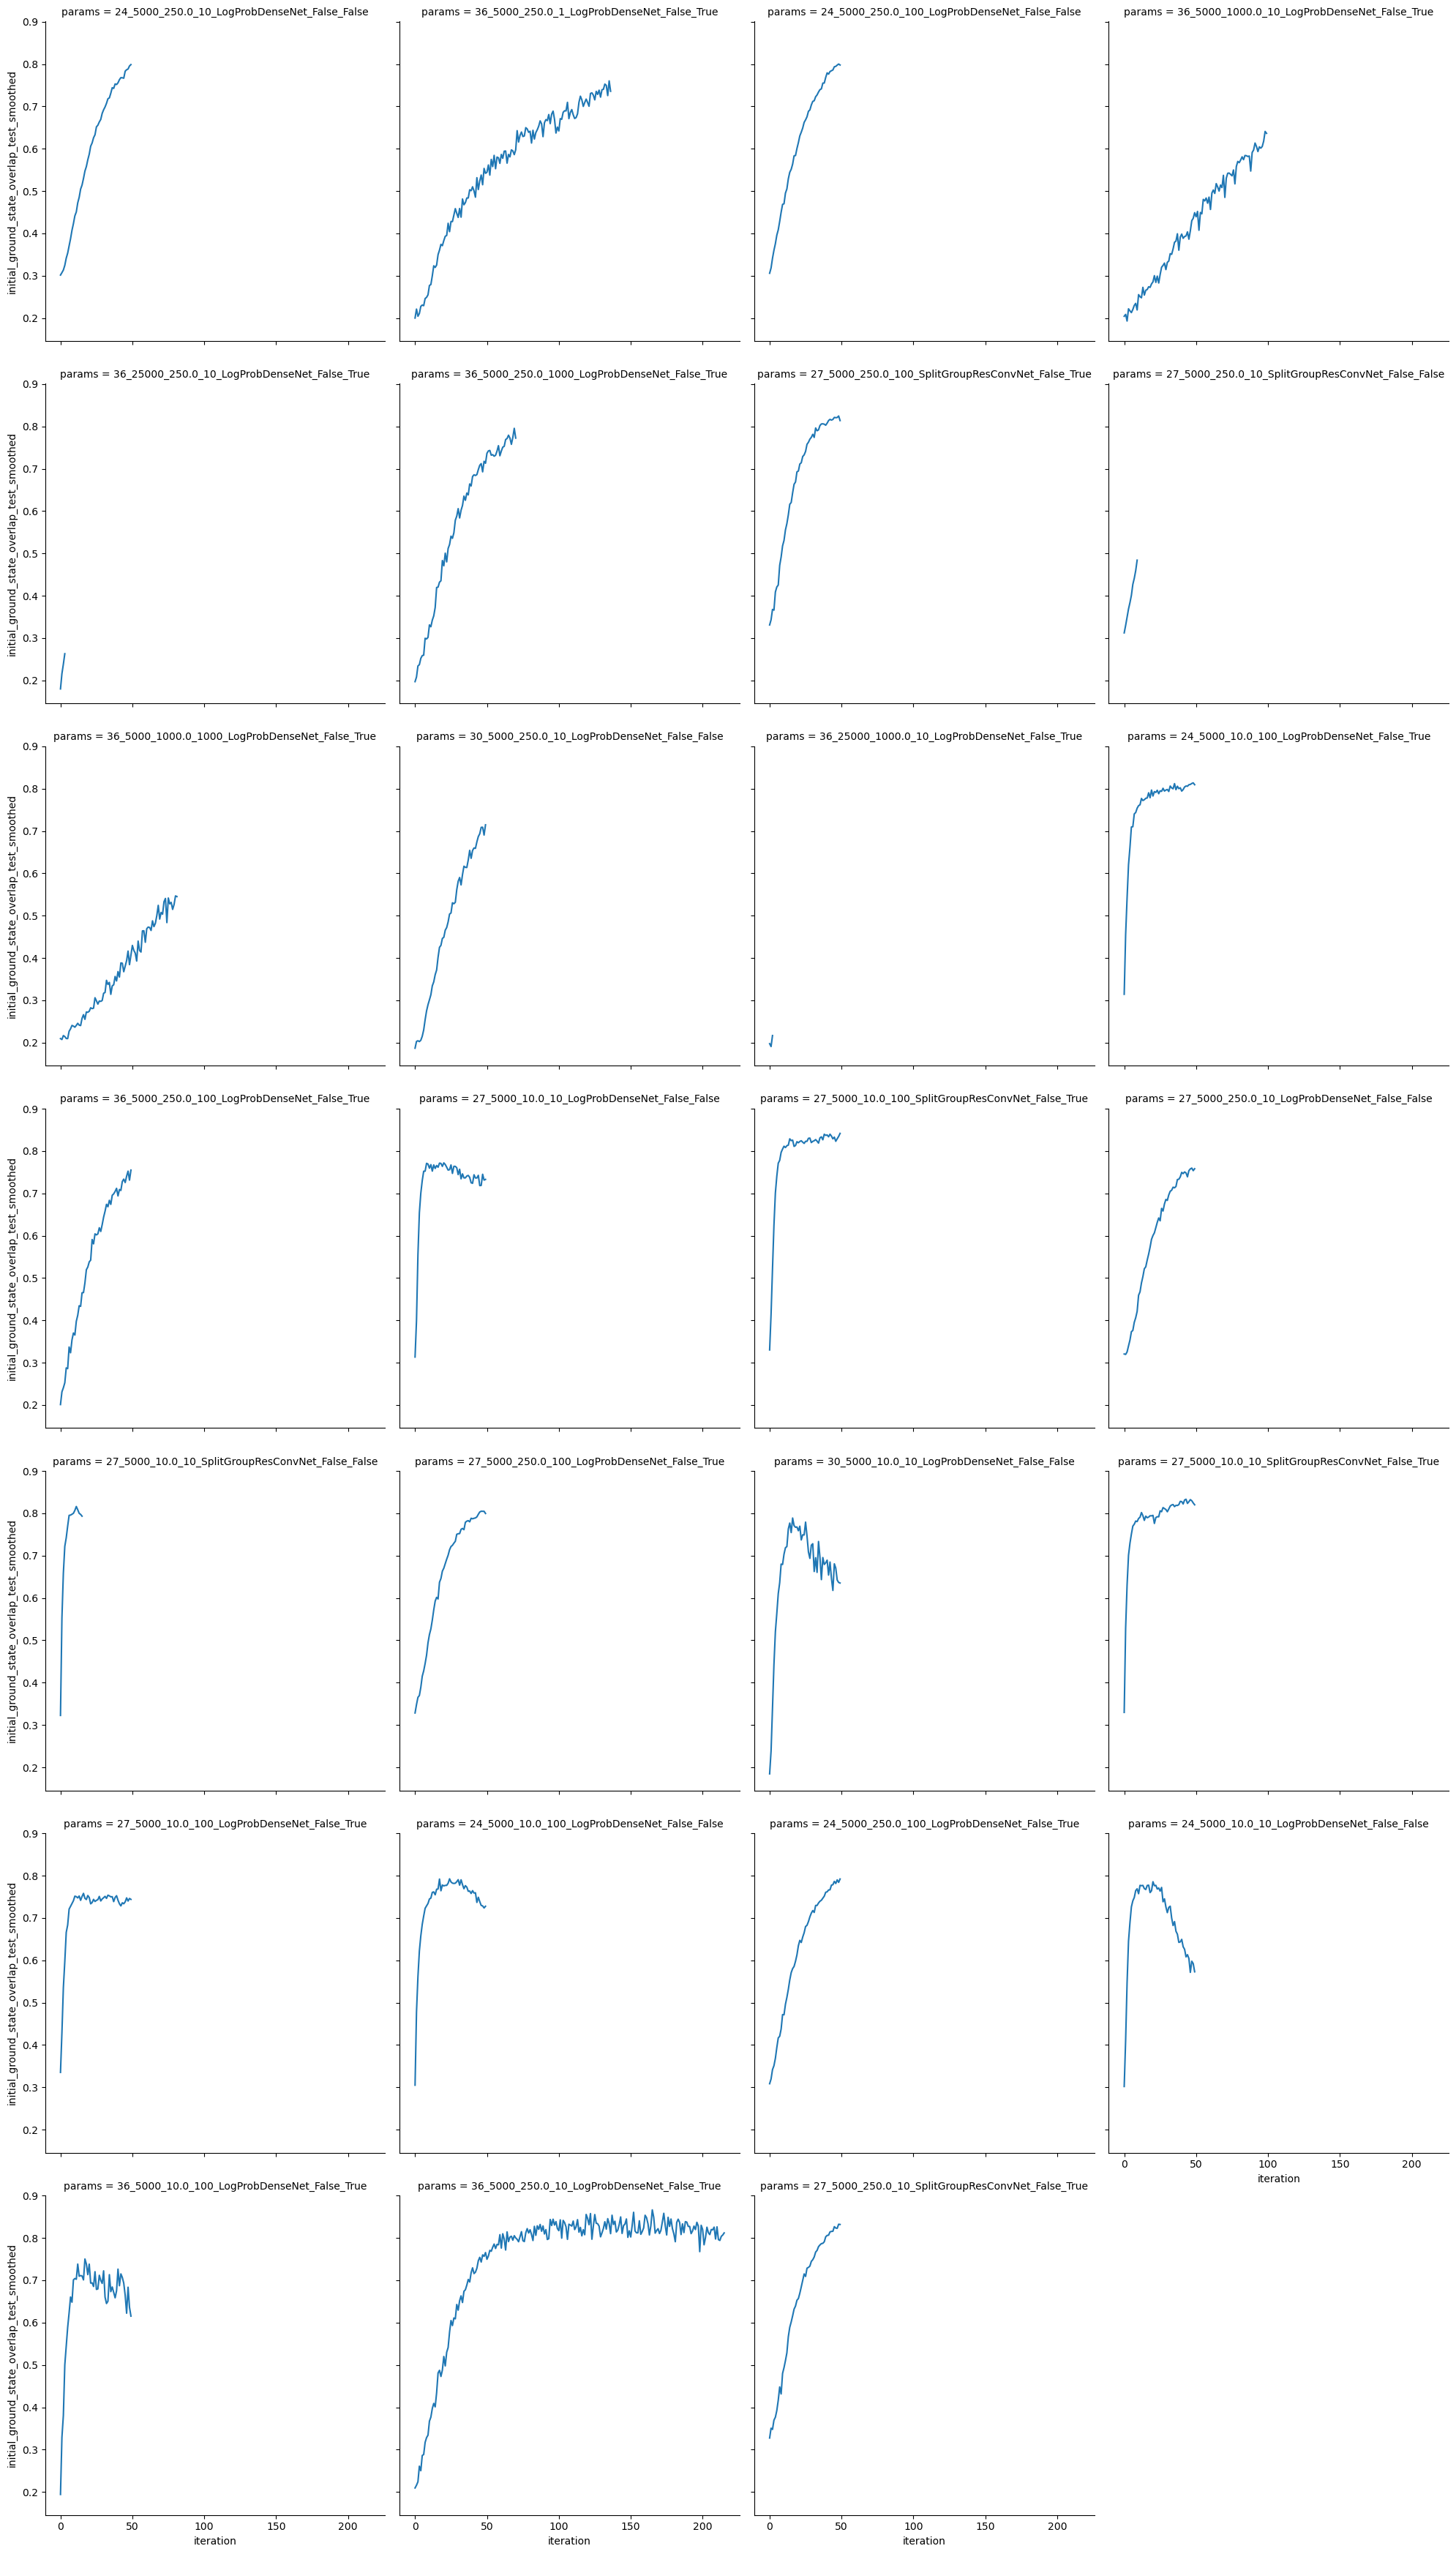

In [29]:
params = ['n_spins', 'n_samples', 'energy_baseline', 'epochs', 'net', 'reset_network', 'use_symmetries']
sns.relplot(
    data=overlaps_df
    .assign(
        initial_ground_state_overlap_test_smoothed=lambda df: df.groupby(
            params
        )["initial_ground_state_overlap_test"].transform(
            lambda x: x.rolling(window=1, center=True).mean()
        ),
        params=concat_columns(params),
    ),
    #.pipe(to(str, ["energy_baseline", "n_samples", "epochs"])),
    x="iteration",
    y="initial_ground_state_overlap_test_smoothed",
    # col="epochs",
    # row="energy_baseline",
    # hue="net_epochs",
    kind="line",
    col="params",
    col_wrap=4
)

In [15]:
describe(overlaps_df.query("n_spins == 27"))

alpha
  - None
mode
  - power
lattice
  - KagomeLattice12x12_isotropic_factor_149-151-152-182-183-184-185-186-187-188-189-190-217-218-219-220-221-222-223-224-225-252-253-254-255-256-258
reset_network
  - False
net
  - SplitGroupResConvNet
  - LogProbDenseNet
use_symmetries
  - True
  - False
lattice_name
  - kagome27
early_stop
  - False
iteration
  : [0.000	23.392	49.000]
initial_ground_state_overlap_test
  : [0.312	0.695	0.842]
new_ground_state_overlap_test
  : [0.179	0.378	0.528]
run
  : [0.000	0.000	0.000]
n_samples
  : [5000.000	5000.000	5000.000]
energy_baseline
  : [10.000	128.310	250.000]
n_spins
  : [27.000	27.000	27.000]
epochs
  : [10.000	52.254	100.000]
epoch
  : [nan	nan	nan]
power_iterations
  : [50.000	50.000	50.000]


In [18]:
overlaps_df.columns

Index(['iteration', 'initial_ground_state_overlap_test',
       'new_ground_state_overlap_test', 'alpha', 'run', 'mode', 'n_samples',
       'lattice', 'energy_baseline', 'n_spins', 'epochs', 'reset_network',
       'net', 'use_symmetries', 'epoch', 'lattice_name', 'power_iterations',
       'early_stop'],
      dtype='object')

/nix/store/nnnbq7bf556rhr0s8sgwwnr4kg1wqhn5-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


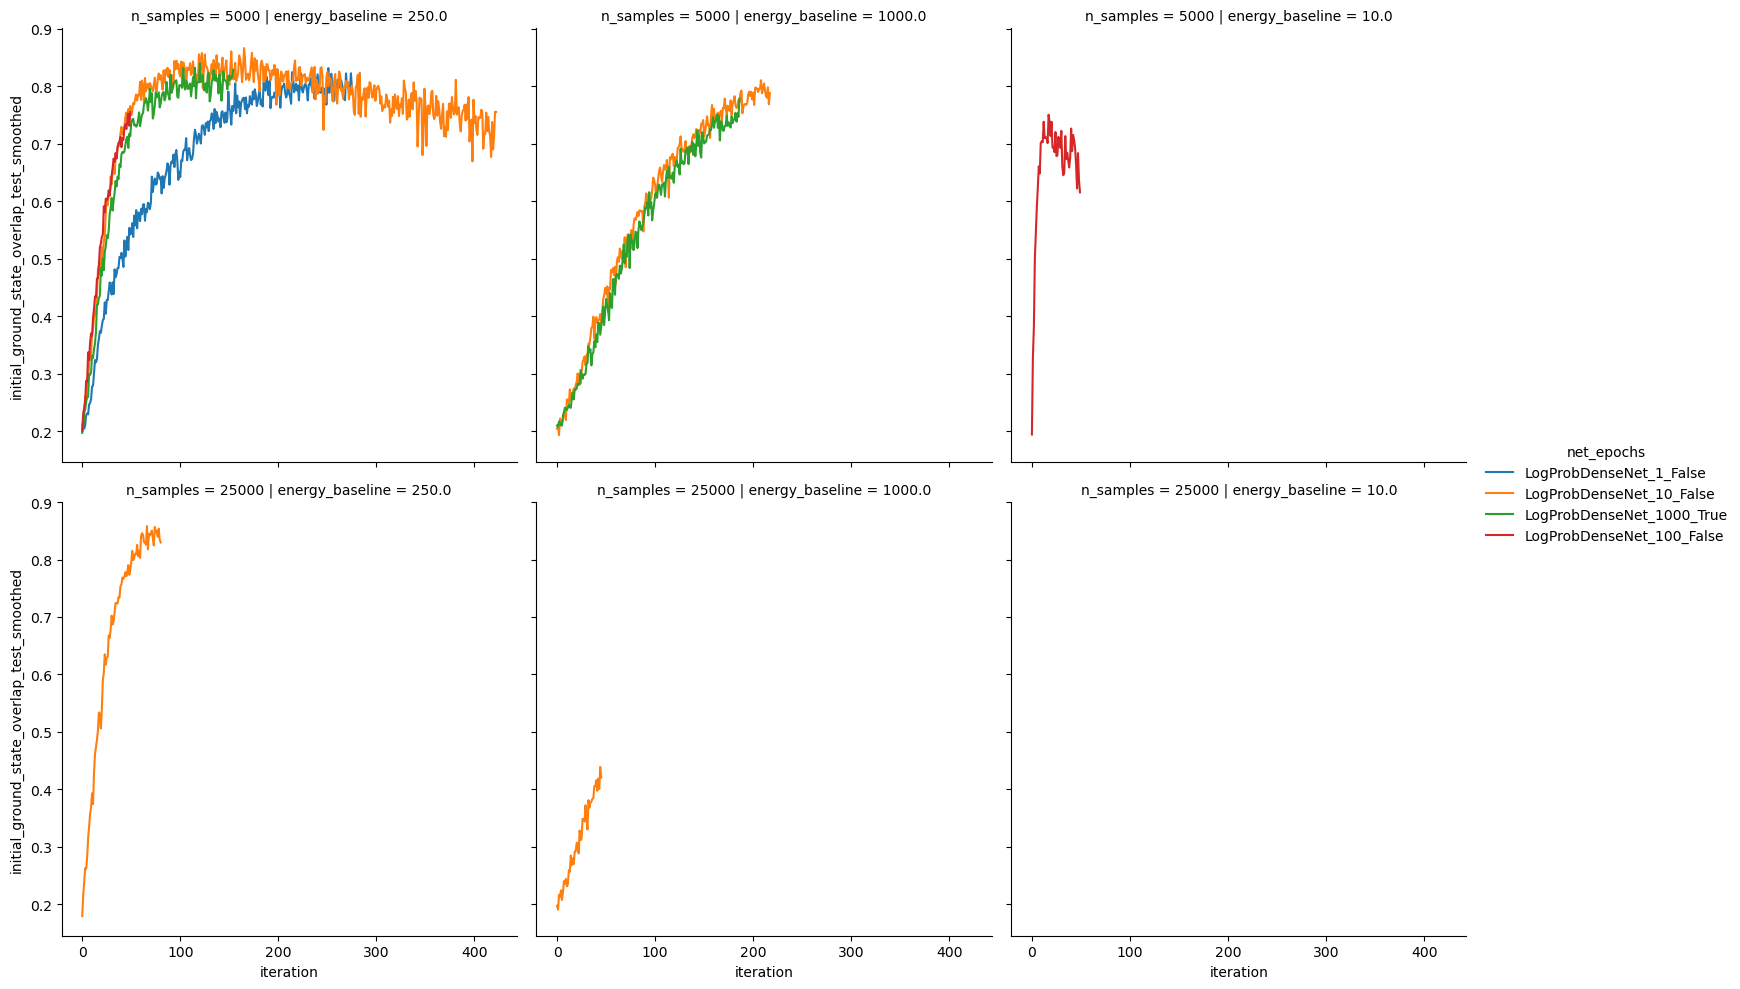

In [37]:
sns.relplot(
    data=overlaps_df.query("n_spins == 36")
    .assign(
        initial_ground_state_overlap_test_smoothed=lambda df: df.groupby(params)[
            "initial_ground_state_overlap_test"
        ].transform(lambda x: x.rolling(window=1, center=True).mean()),
        net_epochs=concat_columns(["net", "epochs", "early_stop"]),
    )
    .pipe(to(str, ["energy_baseline", "n_samples", "epochs"])),
    x="iteration",
    y="initial_ground_state_overlap_test_smoothed",
    # col="epochs",
    hue="net_epochs",
    col="energy_baseline",
    kind="line",
    row="n_samples"
)

In [34]:
overlaps_df.query('early_stop')['epoch'].value_counts()

epoch
1.0     67
2.0     47
3.0     26
4.0      9
10.0     1
8.0      1
7.0      1
5.0      1
Name: count, dtype: int64

In [ ]:
# (ggplot(overlaps_df.dropna(subset=['energy_baseline']), aes(x='iteration', y='new_ground_state_overlap_test', color='energy_baseline'))
#     + geom_point() + geom_smooth(method='loess')
#     + facet_grid('n_samples ~ lattice') + theme_minimal())

In [ ]:
# sns.relplot(
#     overlaps_df.query("lattice == 'KagomeLattice2x3'").pipe(to_cat("energy_baseline")),
#     x="iteration",
#     y="new_ground_state_overlap_test",
#     hue="energy_baseline",
#     kind="line",
#     row="lattice",
# )
# plt.axhline(1, ls='--', color='C4')
# plt.axhline(0.9, ls='--', color='C4')


In [ ]:
# sns.relplot(
#     overlaps_df.query("mode == 'power'"),
#     x="iteration",
#     y="new_ground_state_overlap_test",
#     hue="lattice",
#     kind="line",
# )
# plt.axhline(1, ls='--', color='C4')
# plt.axhline(0.9, ls='--', color='C4')
